# Household Consumption and Income Dynamics

## Project Overview

This project analyzes the relationship between household consumption, income, prices, economic activity, and employment across U.S. states using panel data.

The analysis applies panel-data econometric methods, including Fixed Effects and Random Effects models, logarithmic specifications, dynamic analysis, robustness checks, and a Hausman test.

## Research Objective

The main objective is to examine how changes in real personal income and other economic factors are associated with household consumption across U.S. states over time.

## Methods

- Panel Data Analysis
- Fixed Effects (FE)
- Random Effects (RE)
- Hausman Test
- Log-linear regression models
- Dynamic panel specification
- Robustness checks
- Descriptive and correlation analysis

## Tools

Python · Pandas · Matplotlib · linearmodels · Google Colab



## 1. Environment Setup


In [5]:
# =========================================
# 1. INSTALL REQUIRED PACKAGES
# =========================================

!pip install linearmodels openpyxl --quiet

In [6]:
# =========================================
# 2. IMPORT LIBRARIES
# =========================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from linearmodels.panel import PanelOLS, RandomEffects

## 2. Access the Project Repository

The dataset is stored in the public GitHub repository and loaded directly into the Colab environment.


In [7]:
# =========================================
# 3. ACCESS GITHUB REPOSITORY
# =========================================

REPO_ROOT = Path("/content/household-consumption-income-dynamics")

if not REPO_ROOT.exists():
    !git clone https://github.com/i0ana-stack/household-consumption-income-dynamics.git
else:
    !git -C /content/household-consumption-income-dynamics pull

DATA_PATH = REPO_ROOT / "data" / "PANEL_DATA_US.xlsx"

print(f"Repository: {REPO_ROOT}")
print(f"Dataset: {DATA_PATH}")

Already up to date.
Repository: /content/household-consumption-income-dynamics
Dataset: /content/household-consumption-income-dynamics/data/PANEL_DATA_US.xlsx


## 3. Load and Inspect the Data


In [8]:
# =========================================
# 4. LOAD DATA
# =========================================

df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (884, 10)


In [9]:
# =========================================
# 5. BASIC DATA CHECKS
# =========================================

print("First five observations:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isna().sum())

First five observations:


,STATE,YEAR,PCE (mil.$),Real PI (mil.2017$),RPPs (index),Real GDP (mil.2017$),Employment (jobs),Personal Income (mil.$),PI Per Capita ($),Real PI Per Capita (2017$)
0,Alabama,2008,130009.5,199198.2,88.901,200967.4,2582600,157780.3,33441,42219
1,Alabama,2009,128265.5,199669.6,87.786,194192.1,2479511,155666.9,32717,41966
2,Alabama,2010,132314.4,199704.6,89.783,199455.0,2460305,162068.8,33848,41709
3,Alabama,2011,136772.4,201259.2,90.011,201372.8,2497974,167882.2,34884,41819
4,Alabama,2012,139950.6,201300.9,90.559,203675.5,2503656,172101.5,35559,41592



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   STATE                       884 non-null    object 
 1   YEAR                        884 non-null    int64  
 2   PCE (mil.$)                 884 non-null    float64
 3   Real PI (mil.2017$)         884 non-null    float64
 4   RPPs (index)                884 non-null    float64
 5   Real GDP (mil.2017$)        884 non-null    float64
 6   Employment (jobs)           884 non-null    int64  
 7   Personal Income (mil.$)     884 non-null    float64
 8   PI Per Capita ($)           884 non-null    int64  
 9   Real PI Per Capita (2017$)  884 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 69.2+ KB

Missing values:
STATE                         0
YEAR                          0
PCE (mil.$)                   0
Real PI (mil.

## 4. Panel Data Structure

The dataset contains observations for multiple U.S. state-level entities observed repeatedly over time. The panel index is defined by state and year.

In [10]:
# =========================================
# 6. SET PANEL STRUCTURE
# =========================================

df = df.set_index(["STATE", "YEAR"])

print("Panel structure:")
print(df.index.names)

print(f"\nNumber of observations: {len(df)}")
print(f"Number of states/entities: {df.index.get_level_values('STATE').nunique()}")
print(
    f"Years: "
    f"{df.index.get_level_values('YEAR').min()}–"
    f"{df.index.get_level_values('YEAR').max()}"
)

Panel structure:
['STATE', 'YEAR']

Number of observations: 884
Number of states/entities: 52
Years: 2008–2024


## 5. Descriptive Statistics

Descriptive statistics are used to summarize the scale and distribution of the main economic variables in the panel.

In [11]:
# =========================================
# 7. DESCRIPTIVE STATISTICS
# =========================================

variables = [
    "PCE (mil.$)",
    "Real PI (mil.2017$)",
    "RPPs (index)",
    "Real GDP (mil.2017$)",
    "Employment (jobs)",
    "Personal Income (mil.$)",
    "PI Per Capita ($)",
    "Real PI Per Capita (2017$)"
]

descriptive_stats = df[variables].describe().T

print("=== DESCRIPTIVE STATISTICS ===")
display(descriptive_stats)

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
PCE (mil.$),884.0,5.171627e+05,1.887839e+06,18653.200,66136.25000,1.675598e+05,3.393250e+05,1.989601e+07
Real PI (mil.2017$),884.0,6.360375e+05,2.279228e+06,27997.800,81061.70000,2.200996e+05,4.142877e+05,2.013294e+07
RPPs (index),884.0,9.755146e+01,6.878319e+00,85.018,91.87375,9.705350e+01,1.023637e+02,1.142420e+02
Real GDP (mil.2017$),884.0,7.421353e+05,2.666236e+06,29565.700,91834.02500,2.324788e+05,4.882802e+05,2.335844e+07
Employment (jobs),884.0,7.408213e+06,2.635708e+07,385075.000,920559.25000,2.533227e+06,4.871016e+06,2.181812e+08
Personal Income (mil.$),884.0,6.530947e+05,2.389978e+06,24912.800,79033.50000,2.122809e+05,4.223959e+05,2.489761e+07
PI Per Capita ($),884.0,5.133240e+04,1.303177e+04,30220.000,41191.00000,4.863300e+04,5.921425e+04,1.111850e+05
Real PI Per Capita (2017$),884.0,5.136027e+04,7.729195e+03,35790.000,45754.25000,5.068500e+04,5.614675e+04,8.187200e+04


## 6. Correlation Analysis

The correlation matrix provides an initial view of the relationships among the main aggregate economic variables.

The high correlations among consumption, real personal income, real GDP, and employment motivate caution when interpreting models containing several aggregate predictors simultaneously.

In [12]:
# =========================================
# 8. CORRELATION MATRIX
# =========================================

correlation_variables = [
    "PCE (mil.$)",
    "Real PI (mil.2017$)",
    "Real GDP (mil.2017$)",
    "Employment (jobs)",
    "RPPs (index)"
]

correlation_matrix = df[correlation_variables].corr()

print("=== CORRELATION MATRIX ===")
display(correlation_matrix)

=== CORRELATION MATRIX ===


,PCE (mil.$),Real PI (mil.2017$),Real GDP (mil.2017$),Employment (jobs),RPPs (index)
PCE (mil.$),1.000000,0.994327,0.992885,0.987661,0.107857
Real PI (mil.2017$),0.994327,1.000000,0.999082,0.997530,0.102628
Real GDP (mil.2017$),0.992885,0.999082,1.000000,0.998569,0.116467
Employment (jobs),0.987661,0.997530,0.998569,1.000000,0.099206
RPPs (index),0.107857,0.102628,0.116467,0.099206,1.000000


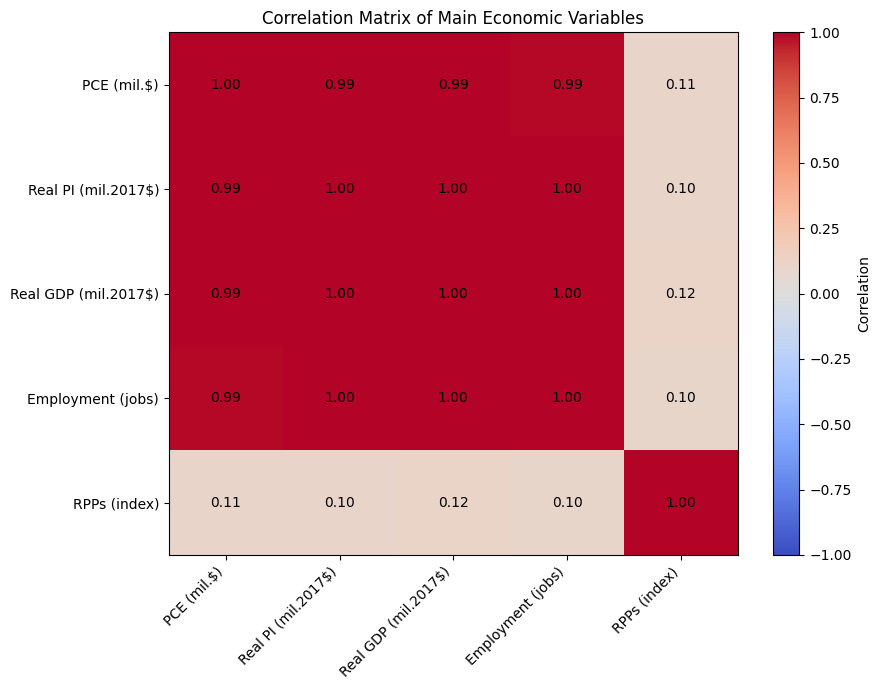

In [13]:
# =========================================
# 8.1 CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Main Economic Variables")

plt.tight_layout()
plt.show()

## 7. Model 1 — Full Fixed Effects Model

The first specification includes real personal income, real GDP, employment, and regional price levels, together with entity and time fixed effects.

Clustered standard errors are used at the entity level.

In [14]:
# =========================================
# 9. MODEL 1 — FULL FIXED EFFECTS
# =========================================

model1 = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + '
    'Q("Real GDP (mil.2017$)") + Q("Employment (jobs)") + '
    'Q("RPPs (index)") + EntityEffects + TimeEffects',
    data=df
)

results1 = model1.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== MODEL 1: FULL FIXED EFFECTS ===")
print(results1)

=== MODEL 1: FULL FIXED EFFECTS ===
                          PanelOLS Estimation Summary                           
Dep. Variable:       Q('PCE (mil.$)')   R-squared:                        0.9662
Estimator:                   PanelOLS   R-squared (Between):              0.1423
No. Observations:                 884   R-squared (Within):               0.9667
Date:                Wed, Oct 07 2026   R-squared (Overall):              0.1818
Time:                        20:20:54   Log-likelihood                -1.119e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5807.5
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(4,812)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):           7

### Interpretation

The full fixed-effects specification shows substantial explanatory power within states, but the aggregate predictors are highly correlated.

Real GDP is statistically significant at the 5% level, while real personal income and employment are not statistically significant in this specification. The poolability test rejects the hypothesis that the observations can be treated as a common pooled model without entity-specific effects.

The specification therefore motivates a more focused model that reduces overlap among highly correlated aggregate variables.

## 8. Model 2 — Refined Fixed Effects Model

The second specification removes real GDP and employment while retaining real personal income and the regional price index.

This provides a more focused specification after considering the strong correlations among the aggregate variables.

In [15]:
# =========================================
# 10. MODEL 2 — REFINED FIXED EFFECTS
# =========================================

model2 = PanelOLS.from_formula(
    'Q("PCE (mil.$)") ~ Q("Real PI (mil.2017$)") + '
    'Q("RPPs (index)") + EntityEffects + TimeEffects',
    data=df
)

results2 = model2.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== MODEL 2: REFINED FIXED EFFECTS ===")
print(results2)

=== MODEL 2: REFINED FIXED EFFECTS ===
                          PanelOLS Estimation Summary                           
Dep. Variable:       Q('PCE (mil.$)')   R-squared:                        0.9105
Estimator:                   PanelOLS   R-squared (Between):              0.6042
No. Observations:                 884   R-squared (Within):               0.9106
Date:                Wed, Oct 07 2026   R-squared (Overall):              0.6189
Time:                        20:21:40   Log-likelihood                -1.162e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4139.9
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(2,814)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):         

### Interpretation

After removing real GDP and employment, the coefficient on real personal income becomes positive and statistically significant, while the regional price index remains statistically insignificant.

This specification illustrates how coefficient estimates can change substantially when highly correlated aggregate predictors are removed.

## 9. Model 3 — Log-Linear Fixed Effects Model

A logarithmic specification is estimated to express the relationship between real personal income and consumption in elasticity terms.

In [16]:
# =========================================
# 11. PREPARE LOG VARIABLES
# =========================================

df["log_PCE"] = np.log(df["PCE (mil.$)"])
df["log_RPI"] = np.log(df["Real PI (mil.2017$)"])

In [17]:
# =========================================
# 12. MODEL 3 — LOG-LINEAR FIXED EFFECTS
# =========================================

model3 = PanelOLS.from_formula(
    "log_PCE ~ log_RPI + EntityEffects + TimeEffects",
    data=df
)

results3 = model3.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== MODEL 3: LOG-LINEAR FIXED EFFECTS ===")
print(results3)

=== MODEL 3: LOG-LINEAR FIXED EFFECTS ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                log_PCE   R-squared:                        0.7388
Estimator:                   PanelOLS   R-squared (Between):              0.9100
No. Observations:                 884   R-squared (Within):               0.6465
Date:                Wed, Oct 07 2026   R-squared (Overall):              0.9099
Time:                        20:23:08   Log-likelihood                    2275.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2304.9
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(1,815)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):      

### Interpretation

The estimated coefficient on real personal income is 0.6867 and is statistically significant.

Because both variables are expressed in logarithms, the coefficient can be interpreted as an elasticity: a 1% increase in real personal income is associated with approximately a 0.69% increase in real personal consumption expenditure, holding state and year fixed.

This is an association rather than a causal estimate.

## 10. Model 4 — Dynamic Fixed Effects Model

Consumption may exhibit persistence over time. To examine this, the model is extended by including the previous year's log consumption as a lagged explanatory variable.

In [18]:
# =========================================
# 13. CREATE LAGGED CONSUMPTION VARIABLE
# =========================================

df["lag_log_PCE"] = (
    df.groupby(level="STATE")["log_PCE"]
    .shift(1)
)

print("Missing values in lagged consumption:")
print(df["lag_log_PCE"].isna().sum())

Missing values in lagged consumption:
52


In [19]:
# =========================================
# 14. MODEL 4 — DYNAMIC FIXED EFFECTS
# =========================================

dynamic_df = df.dropna(subset=["lag_log_PCE"])

model4 = PanelOLS.from_formula(
    "log_PCE ~ log_RPI + lag_log_PCE + EntityEffects + TimeEffects",
    data=dynamic_df
)

results4 = model4.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== MODEL 4: DYNAMIC FIXED EFFECTS ===")
print(results4)

=== MODEL 4: DYNAMIC FIXED EFFECTS ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                log_PCE   R-squared:                        0.9462
Estimator:                   PanelOLS   R-squared (Between):              0.9998
No. Observations:                 832   R-squared (Within):               0.9616
Date:                Wed, Oct 07 2026   R-squared (Overall):              0.9998
Time:                        20:23:58   Log-likelihood                    2811.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6710.1
Entities:                          52   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(2,763)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-statistic (robust):         

### Interpretation

The lagged consumption coefficient is positive and statistically significant, indicating strong persistence in consumption over time.

Once lagged consumption is included, the coefficient on real personal income falls from 0.6867 in the static log-linear model to 0.1963.

This suggests that part of the association observed in the static model is related to persistence in consumption. The dynamic specification remains an association model and should not be interpreted as establishing causal effects.

## 11. Model 5 — Per-Worker Robustness Model

As a robustness check, the analysis is repeated using per-worker measures of consumption and real personal income.

This specification reduces the influence of differences in aggregate state size and focuses on the relationship between consumption and income after scaling both variables by employment.

In [20]:
# =========================================
# 15. CREATE PER-WORKER VARIABLES
# =========================================

df["PCE_per_worker"] = (
    df["PCE (mil.$)"] * 1_000_000
    / df["Employment (jobs)"]
)

df["RPI_per_worker"] = (
    df["Real PI (mil.2017$)"] * 1_000_000
    / df["Employment (jobs)"]
)

df["log_PCE_worker"] = np.log(df["PCE_per_worker"])
df["log_RPI_worker"] = np.log(df["RPI_per_worker"])

In [21]:
# =========================================
# 16. MODEL 5 — PER-WORKER LOG FIXED EFFECTS
# =========================================

model5 = PanelOLS.from_formula(
    "log_PCE_worker ~ log_RPI_worker + EntityEffects + TimeEffects",
    data=df
)

results5 = model5.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== MODEL 5: PER-WORKER LOG FIXED EFFECTS ===")
print(results5)

=== MODEL 5: PER-WORKER LOG FIXED EFFECTS ===
                          PanelOLS Estimation Summary                           
Dep. Variable:         log_PCE_worker   R-squared:                        0.2238
Estimator:                   PanelOLS   R-squared (Between):              0.5472
No. Observations:                 884   R-squared (Within):               0.2613
Date:                Wed, Oct 07 2026   R-squared (Overall):              0.5472
Time:                        20:24:38   Log-likelihood                    2438.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      234.93
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(1,815)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):  

### Interpretation

The per-worker robustness model shows a positive and statistically significant association between real personal income per worker and consumption per worker.

The estimated elasticity is 0.3203, meaning that a 1% increase in real personal income per worker is associated with approximately a 0.32% increase in consumption per worker, holding state and year fixed.

The coefficient is smaller than the 0.6867 estimate from the main log-linear fixed-effects model, indicating that the estimated income-consumption relationship is sensitive to how the variables are scaled.

This specification provides a robustness check by reducing the influence of differences in aggregate state size.

## 12. Random Effects Model

As an alternative to the fixed-effects specification, a Random Effects model is estimated using the main log-transformed variables.

The Random Effects specification assumes that unobserved state-specific effects are uncorrelated with the explanatory variable.

In [22]:
# =========================================
# 17. RANDOM EFFECTS MODEL
# =========================================

model_re = RandomEffects.from_formula(
    "log_PCE ~ log_RPI",
    data=df
)

results_re = model_re.fit()

print("=== RANDOM EFFECTS MODEL ===")
print(results_re)

=== RANDOM EFFECTS MODEL ===
                        RandomEffects Estimation Summary                        
Dep. Variable:                log_PCE   R-squared:                        0.9981
Estimator:              RandomEffects   R-squared (Between):              0.9999
No. Observations:                 884   R-squared (Within):               0.8040
Date:                Wed, Oct 07 2026   R-squared (Overall):              0.9999
Time:                        20:25:26   Log-likelihood                    842.49
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   4.687e+05
Entities:                          52   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                   F(1,883)
Min Obs:                       17.000                                           
Max Obs:                       17.000   F-statistic (robust):          4.687e+05

### Interpretation

The Random Effects model estimates an elasticity of 0.9827 between real personal income and consumption.

This estimate is substantially larger than the 0.6867 coefficient from the Fixed Effects model. The difference motivates a formal comparison of the two specifications using the Hausman test.

## 13. Hausman Test — Fixed Effects vs Random Effects

The Hausman test compares the Fixed Effects and Random Effects estimates.

The null hypothesis is that the Random Effects estimator is consistent, meaning that the unobserved state-specific effects are not correlated with the explanatory variables.

A statistically significant test result provides evidence against the Random Effects specification and supports the use of Fixed Effects.

In [23]:
# =========================================
# 18. HAUSMAN TEST — FE VS RE
# =========================================

fe_results = results3
re_results = results_re

# Compare common coefficients
common_params = fe_results.params.index.intersection(
    re_results.params.index
)

b_fe = fe_results.params[common_params]
b_re = re_results.params[common_params]

b_diff = b_fe - b_re

# Difference in covariance matrices
v_fe = fe_results.cov.loc[
    common_params,
    common_params
]

v_re = re_results.cov.loc[
    common_params,
    common_params
]

v_diff = v_fe - v_re

# Use the pseudo-inverse because the covariance
# difference can be singular or nearly singular.
hausman_stat = float(
    b_diff.T @ np.linalg.pinv(v_diff) @ b_diff
)

hausman_df = len(b_diff)

hausman_pvalue = 1 - stats.chi2.cdf(
    hausman_stat,
    hausman_df
)

print("=== HAUSMAN TEST: FIXED EFFECTS VS RANDOM EFFECTS ===")
print(f"Hausman statistic: {hausman_stat:.4f}")
print(f"Degrees of freedom: {hausman_df}")
print(f"P-value: {hausman_pvalue:.6f}")

if hausman_pvalue < 0.05:
    print("Result: Reject the null hypothesis.")
    print("Fixed Effects is preferred over Random Effects.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("Random Effects is not rejected by the Hausman test.")

=== HAUSMAN TEST: FIXED EFFECTS VS RANDOM EFFECTS ===
Hausman statistic: 70.0301
Degrees of freedom: 1
P-value: 0.000000
Result: Reject the null hypothesis.
Fixed Effects is preferred over Random Effects.


### Hausman Test Result

The Hausman test produces a statistic of 70.0301 with 1 degree of freedom and a p-value below 0.001.

The null hypothesis is rejected, providing evidence against the Random Effects specification. Therefore, the Fixed Effects model is preferred for the main log-linear specification.

The estimated coefficient also differs substantially between the two approaches: 0.6867 under Fixed Effects compared with 0.9827 under Random Effects. This difference supports the importance of accounting for unobserved state-specific effects when estimating the relationship between real personal income and consumption.

## 14. Model Comparison

The table below summarizes the main coefficient estimates across the alternative model specifications.

The models differ in how they account for aggregate economic factors, dynamic persistence, variable scaling, and unobserved state-specific effects.

In [25]:
# =========================================
# 19. MODEL COMPARISON
# =========================================

model_comparison = pd.DataFrame({
    "Model": [
        "Model 1: Full FE",
        "Model 2: Refined FE",
        "Model 3: Log FE",
        "Model 4: Dynamic FE",
        "Model 5: Per-Worker Log FE",
        "Random Effects"
    ],
    "Specification": [
        "Levels + GDP + Employment + RPP",
        "Levels + Real PI + RPP",
        "Log PCE ~ Log Real PI",
        "Log PCE ~ Log Real PI + Lagged PCE",
        "Log PCE/worker ~ Log Real PI/worker",
        "Log PCE ~ Log Real PI"
    ],
    "Income Coefficient": [
        results1.params["Q('Real PI (mil.2017$)')"],
        results2.params["Q('Real PI (mil.2017$)')"],
        results3.params["log_RPI"],
        results4.params["log_RPI"],
        results5.params["log_RPI_worker"],
        results_re.params["log_RPI"]
    ],
    "P-value": [
        results1.pvalues["Q('Real PI (mil.2017$)')"],
        results2.pvalues["Q('Real PI (mil.2017$)')"],
        results3.pvalues["log_RPI"],
        results4.pvalues["log_RPI"],
        results5.pvalues["log_RPI_worker"],
        results_re.pvalues["log_RPI"]
    ]
})

print("=== MODEL COMPARISON ===")
display(model_comparison.round(4))

=== MODEL COMPARISON ===


,Model,Specification,Income Coefficient,P-value
0,Model 1: Full FE,Levels + GDP + Employment + RPP,-0.2415,0.4219
1,Model 2: Refined FE,Levels + Real PI + RPP,1.3057,0.0000
2,Model 3: Log FE,Log PCE ~ Log Real PI,0.6867,0.0000
3,Model 4: Dynamic FE,Log PCE ~ Log Real PI + Lagged PCE,0.1963,0.0000
4,Model 5: Per-Worker Log FE,Log PCE/worker ~ Log Real PI/worker,0.3203,0.0000
5,Random Effects,Log PCE ~ Log Real PI,0.9827,0.0000


### Model Comparison — Key Findings

The estimated association between real personal income and consumption varies across specifications.

The full fixed-effects model produces a negative and statistically insignificant coefficient for real personal income, while removing highly correlated aggregate controls in the refined specification produces a positive and statistically significant coefficient.

The log-linear Fixed Effects model estimates an elasticity of 0.6867. After accounting for lagged consumption, the income coefficient falls to 0.1963, while the lagged consumption term is strongly significant, indicating substantial persistence in consumption over time.

The per-worker robustness specification produces an elasticity of 0.3203, providing a positive and statistically significant relationship after scaling consumption and income by employment.

The Random Effects model estimates a substantially larger elasticity of 0.9827. However, the Hausman test rejects the Random Effects specification in favor of Fixed Effects.

Overall, the results show that the estimated income-consumption relationship is sensitive to model specification, dynamic persistence, and variable scaling. The Fixed Effects framework is preferred based on the Hausman test.